# Hotel Booking Demand - Cross-Technique Analysis

Notebook này trình bày kết quả chính của đồ án: kết hợp Classification và Clustering để phân tích rủi ro hủy booking.


## 01. Bài toán nghiệp vụ

Mục tiêu nghiệp vụ của phân tích này là hỗ trợ các nhà quản lý khách sạn hiểu rõ hành vi của khách hàng nhằm tối ưu hóa doanh thu và giảm thiểu rủi ro từ việc hủy phòng (`is_canceled`). Phân tích sử dụng dữ liệu lịch sử để nhận diện sớm các booking có nguy cơ hủy cao, từ đó đưa ra quyết sách điều lệ đặt cọc phù hợp.


## 02. Câu hỏi phân tích
1. Những đặc điểm của booking có liên quan đến khả năng hủy phòng hay không?
2. Các booking có thể được chia thành những nhóm hành vi có mức rủi ro hủy khác nhau hay không?

Classification được dùng để trả lời khả năng dự đoán hủy phòng. Clustering được dùng để tìm các nhóm booking và so sánh tỷ lệ hủy giữa các nhóm.

In [102]:
from pathlib import Path
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42
CLASSIFICATION_SAMPLE_N = 40000
DBSCAN_SAMPLE_N = 15000
DBSCAN_EPS = 9.0

In [103]:
from pathlib import Path

# Khai báo đường dẫn tương đối tính từ nơi đặt file notebook
OUTPUT_DIR = Path("output")

# Lệnh này sẽ tự động khởi tạo thư mục "output" nếu nó chưa tồn tại
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


*Đọc dữ liệu chuẩn bị phân tích.*

In [104]:
def find_processed_data(start=None):
    start = Path.cwd() if start is None else Path(start)

    candidates = [
        start / "data" / "hotel_bookings_processed.csv",
        start / "data" / "processed" / "D1_hotel_booking" / "hotel_bookings_processed.csv",
        start.parent / "data" / "hotel_bookings_processed.csv",
        start.parent / "data" / "processed" / "D1_hotel_booking" / "hotel_bookings_processed.csv",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    for base in [start, *start.parents]:
        candidate = base / "data" / "processed" / "D1_hotel_booking" / "hotel_bookings_processed.csv"
        if candidate.exists():
            return candidate

    return None


DATA_PATH = find_processed_data()

if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy hotel_bookings_processed.csv bằng đường dẫn tương đối."
    )

df_raw = pd.read_csv(DATA_PATH)

RANDOM_STATE = 42
DBSCAN_SAMPLE_N = 15000
DBSCAN_EPS = 9.0

print("Đã đọc dữ liệu:", DATA_PATH)
print("Kích thước:", df_raw.shape)

Đã đọc dữ liệu: e:\CODECNTT\DU_AN\DataMining\data-mining\DO_AN\data\hotel_bookings_processed.csv
Kích thước: (117398, 43)


In [105]:
dataset_scope = pd.DataFrame({
    "Hạng mục": [
        "Dataset gốc",
        "Dữ liệu sau Bài 1",
        "Target phân tích",
        "Classification Bài 2",
        "DBSCAN Bài 4",
        "Ràng buộc quan trọng"
    ],
    "Mô tả": [
        "Hotel Booking Demand, 119,390 dòng x 32 thuộc tính gốc",
        f"{df_raw.shape[0]:,} dòng x {df_raw.shape[1]:,} cột sau xử lý",
        "is_canceled: 0 = không hủy, 1 = hủy",
        f"Dùng sample {CLASSIFICATION_SAMPLE_N:,} dòng",
        f"Dùng sample {DBSCAN_SAMPLE_N:,} dòng",
        "Không so sánh row-level giữa Classification và DBSCAN nếu chưa align sample"
    ]
})

display(dataset_scope)

,Hạng mục,Mô tả
0,Dataset gốc,"Hotel Booking Demand, 119,390 dòng x 32 thuộc ..."
1,Dữ liệu sau Bài 1,"117,398 dòng x 43 cột sau xử lý"
2,Target phân tích,"is_canceled: 0 = không hủy, 1 = hủy"
3,Classification Bài 2,"Dùng sample 40,000 dòng"
4,DBSCAN Bài 4,"Dùng sample 15,000 dòng"
5,Ràng buộc quan trọng,Không so sánh row-level giữa Classification và...


 *Trực quan hóa bằng biểu đồ.*

,is_canceled,meaning,percent
0,0,Không hủy,62.51
1,1,Hủy,37.49


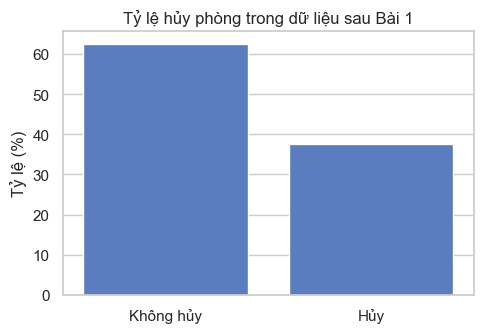

In [106]:
target_summary = (
    df_raw["is_canceled"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .reset_index()
)
target_summary.columns = ["is_canceled", "percent"]
target_summary["meaning"] = target_summary["is_canceled"].map({0: "Không hủy", 1: "Hủy"})
target_summary["percent"] = target_summary["percent"].round(2)

display(target_summary[["is_canceled", "meaning", "percent"]])

plt.figure(figsize=(5, 3.5))
sns.barplot(data=target_summary, x="meaning", y="percent")
plt.title("Tỷ lệ hủy phòng trong dữ liệu sau Bài 1")
plt.xlabel("")
plt.ylabel("Tỷ lệ (%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_ty_le_huy_phong.png", dpi=300) 
plt.show()

## 03. Tóm tắt kết quả kỹ thuật

Tóm tắt các kết quả kỹ thuật được kế thừa từ Bài 2 Classification và Bài 4 Clustering.



In [107]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

# Thêm trực tiếp đường dẫn Path('../data/D1_metrics.csv') vào đầu danh sách
metrics_candidates = [
    Path('../data/D1_metrics.csv'),
    Path('data/D1_metrics.csv'),
    Path('../output/D1_metrics.csv'),
]

metrics_path = next((p for p in metrics_candidates if p.exists()), None)

if metrics_path is None:
    d1_metrics = pd.DataFrame(columns=["dataset", "model", "accuracy", "precision", "recall", "f1", "roc_auc"])
    display(Markdown(
        "**Chưa tìm thấy `D1_metrics.csv`.** "
        "Không điền số liệu Classification ở notebook này. "
        "Hãy chạy lại Bài 2 hoặc đặt file metric vào `bai2-phan-lop/outputs/D1_metrics.csv`."
    ))
else:
    d1_metrics = pd.read_csv(metrics_path)
    print("Đã đọc Classification metrics từ:", metrics_path)
    display(d1_metrics)

Đã đọc Classification metrics từ: data\D1_metrics.csv


,dataset,model,accuracy,precision,recall,f1,roc_auc
0,D1,Decision Tree,0.788375,0.578752,0.850658,0.688844,0.890328
1,D1,Logistic Regression,0.748125,0.528852,0.782115,0.631020,0.841971


*Đọc dữ liệu từ file metric.*

In [108]:
if not d1_metrics.empty:
    metric_cols = [c for c in ["accuracy", "precision", "recall", "f1", "roc_auc"] if c in d1_metrics.columns]
    display(
        d1_metrics
        .sort_values("f1", ascending=False)
        [["model", *metric_cols]]
        .reset_index(drop=True)
    )

    best_cls = d1_metrics.sort_values("f1", ascending=False).iloc[0]
    display(Markdown(
        f"**Mô hình Classification tốt nhất theo F1 trong file metric hiện có:** "
        f"`{best_cls['model']}`. "
        "Kết luận này chỉ dựa trên `D1_metrics.csv`"
    ))
else:
    display(Markdown(
        "Chưa có metric thật của Classification, vì vậy phần synthesis bên dưới chỉ nhắc vai trò của Classification, "
        "không kết luận mô hình nào tốt hơn."
    ))

,model,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.788375,0.578752,0.850658,0.688844,0.890328
1,Logistic Regression,0.748125,0.528852,0.782115,0.631020,0.841971


**Mô hình Classification tốt nhất theo F1 trong file metric hiện có:** `Decision Tree`. Kết luận này chỉ dựa trên `D1_metrics.csv`

In [109]:
clustering_reuse = pd.DataFrame({
    "Thuật toán": ["K-Means", "DBSCAN"],
    "Cấu hình kế thừa từ Bài 4": ["K = 2", "eps = 9.0, min_samples = 88"],
    "Sample dùng để đánh giá/chạy cuối": [
        "K-Means fit trên toàn bộ dữ liệu; Silhouette tính trên sample 15,000",
        "DBSCAN chạy trên sample 15,000"
    ],
    "Số cụm": [2, 3],
    "Silhouette": [0.2226, 0.4146],
    "Davies-Bouldin": [2.5680, 0.9486],
    "Noise (%)": [0.00, 1.72]
})

display(clustering_reuse)

,Thuật toán,Cấu hình kế thừa từ Bài 4,Sample dùng để đánh giá/chạy cuối,Số cụm,Silhouette,Davies-Bouldin,Noise (%)
0,K-Means,K = 2,K-Means fit trên toàn bộ dữ liệu; Silhouette t...,2,0.2226,2.5680,0.00
1,DBSCAN,"eps = 9.0, min_samples = 88","DBSCAN chạy trên sample 15,000",3,0.4146,0.9486,1.72





*Trực quan hóa bằng biểu đồ.*


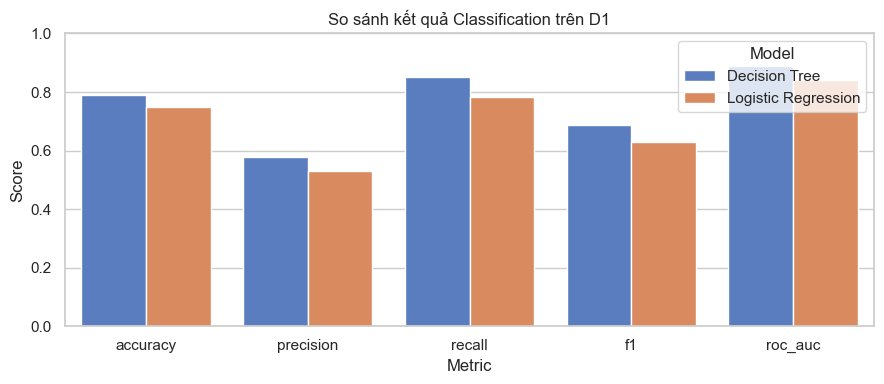

In [110]:
metric_plot = d1_metrics.melt(
    id_vars=["model"],
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(9, 4))
sns.barplot(data=metric_plot, x="metric", y="score", hue="model")
plt.title("So sánh kết quả Classification trên D1")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_classification.png", dpi=300) 
plt.show()

### Nhận xét kỹ thuật kế thừa

Trong Bài 4, DBSCAN có Silhouette cao hơn và Davies-Bouldin thấp hơn K-Means, đồng thời có khả năng tách một phần điểm nhiễu. Vì vậy, phần phân tích chéo bên dưới dùng DBSCAN làm cấu hình clustering chính.

Tuy nhiên, DBSCAN ở đây chỉ được chạy trên sample 15,000 dòng. Do đó các kết luận về cluster cần được hiểu là phân tích trên sample này, không phải kết luận tuyệt đối cho toàn bộ 117,398 dòng.


### 4. Chuẩn bị Không gian Vector: Chuyển đổi dữ liệu phục vụ thuật toán Phân cụm (DBSCAN)

In [111]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = globals().get("RANDOM_STATE", 42)
DBSCAN_SAMPLE_N = globals().get("DBSCAN_SAMPLE_N", 15000)
DBSCAN_EPS = globals().get("DBSCAN_EPS", 9.0)


def find_processed_data(start=None):
    start = Path.cwd() if start is None else Path(start)

    relative_candidates = [
        Path("data/hotel_bookings_processed.csv"),
        Path("data/processed/D1_hotel_booking/hotel_bookings_processed.csv"),
        Path("../data/hotel_bookings_processed.csv"),
        Path("../data/processed/D1_hotel_booking/hotel_bookings_processed.csv"),
        Path("../data-mining/data/processed/D1_hotel_booking/hotel_bookings_processed.csv"),
        Path("../../data/processed/D1_hotel_booking/hotel_bookings_processed.csv"),
    ]

    for rel_path in relative_candidates:
        candidate = start / rel_path
        if candidate.exists():
            return candidate

    for base in [start, *start.parents]:
        candidates = [
            base / "data" / "hotel_bookings_processed.csv",
            base / "data" / "processed" / "D1_hotel_booking" / "hotel_bookings_processed.csv",
        ]
        for candidate in candidates:
            if candidate.exists():
                return candidate

    return None


if "df_raw" not in globals():
    DATA_PATH = find_processed_data()

    if DATA_PATH is None:
        raise FileNotFoundError(
            "Không tìm thấy hotel_bookings_processed.csv bằng đường dẫn tương đối. "
            "Hãy đặt file vào thư mục data/ hoặc data/processed/D1_hotel_booking/ cạnh notebook."
        )

    df_raw = pd.read_csv(DATA_PATH)
    print("Đã đọc lại df_raw từ:", DATA_PATH)
else:
    print("Đã có sẵn df_raw trong bộ nhớ.")

print("Kích thước df_raw:", df_raw.shape)

if "is_canceled" not in df_raw.columns:
    raise ValueError("Thiếu cột is_canceled trong df_raw.")

DROP_COLS = [
    "is_canceled",
    "country",
    "agent",
    "company",
    "reserved_room_type",
    "assigned_room_type",
]

df_cluster_base = df_raw.drop(
    columns=[c for c in DROP_COLS if c in df_raw.columns]
).copy()

month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}

df_enc = df_cluster_base.copy()

if "arrival_date_month" in df_enc.columns:
    df_enc["arrival_date_month"] = df_enc["arrival_date_month"].map(month_map)

cat_to_encode = [
    c for c in ["distribution_channel", "customer_type"]
    if c in df_enc.columns
]
df_enc = pd.get_dummies(df_enc, columns=cat_to_encode, dtype=int)

object_cols = df_enc.select_dtypes(include="object").columns.tolist()
if object_cols:
    raise ValueError(f"Còn cột dạng object chưa encode: {object_cols}")

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_enc),
    columns=df_enc.columns,
    index=df_enc.index
)

X = df_scaled.values

print("df_cluster_base:", df_cluster_base.shape)
print("df_enc:", df_enc.shape)
print("X:", X.shape)


Đã có sẵn df_raw trong bộ nhớ.
Kích thước df_raw: (117398, 43)


df_cluster_base: (117398, 37)
df_enc: (117398, 44)
X: (117398, 44)


*Xử lý chuẩn hóa và mã hóa dữ liệu.*

In [112]:
DROP_COLS = [
    "is_canceled",
    "country",
    "agent",
    "company",
    "reserved_room_type",
    "assigned_room_type",
]

df_cluster_base = df_raw.drop(
    columns=[c for c in DROP_COLS if c in df_raw.columns]
).copy()

month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}

df_enc = df_cluster_base.copy()

if "arrival_date_month" in df_enc.columns:
    df_enc["arrival_date_month"] = df_enc["arrival_date_month"].map(month_map)

cat_to_encode = [
    c for c in ["distribution_channel", "customer_type"]
    if c in df_enc.columns
]

df_enc = pd.get_dummies(df_enc, columns=cat_to_encode, dtype=int)

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_enc),
    columns=df_enc.columns,
    index=df_enc.index
)

X = df_scaled.values

np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(X.shape[0], size=DBSCAN_SAMPLE_N, replace=False)
X_sample = X[sample_idx]

min_samples = 2 * X.shape[1]

dbscan_final = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=min_samples,
    metric="euclidean",
    n_jobs=-1
)

sample_labels = dbscan_final.fit_predict(X_sample)

n_clusters = len(set(sample_labels)) - (1 if -1 in sample_labels else 0)
n_noise = int(np.sum(sample_labels == -1))
noise_rate = n_noise / len(sample_labels) * 100

df_analysis = df_raw.iloc[sample_idx].copy()
df_analysis["cluster"] = sample_labels
df_analysis["cluster_label"] = df_analysis["cluster"].map(
    lambda x: "noise" if x == -1 else f"cluster_{x}"
)

profile_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "total_stay",
    "total_people",
    "total_of_special_requests",
]

profile_cols = [c for c in profile_cols if c in df_analysis.columns]

print("Đã chuẩn bị dữ liệu cho phần phân tích chính.")
print("X_sample:", X_sample.shape)
print(f"DBSCAN: {n_clusters} clusters, noise = {noise_rate:.2f}%")

Đã chuẩn bị dữ liệu cho phần phân tích chính.
X_sample: (15000, 44)
DBSCAN: 3 clusters, noise = 1.72%


### 5. Đánh giá Kiểm định Chất lượng Phân cụm (Clustering Metrics Evaluation)

In [113]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

mask = sample_labels != -1

if len(np.unique(sample_labels[mask])) >= 2:
    sil = silhouette_score(X_sample[mask], sample_labels[mask])
    dbi = davies_bouldin_score(X_sample[mask], sample_labels[mask])
else:
    sil = np.nan
    dbi = np.nan

dbscan_check = pd.DataFrame([{
    "eps": DBSCAN_EPS,
    "min_samples": min_samples,
    "sample_n": len(sample_labels),
    "n_clusters_without_noise": n_clusters,
    "n_noise": n_noise,
    "noise_rate_percent": round(noise_rate, 2),
    "silhouette_without_noise": round(sil, 4) if pd.notna(sil) else np.nan,
    "davies_bouldin_without_noise": round(dbi, 4) if pd.notna(dbi) else np.nan,
}])

display(dbscan_check)


,eps,min_samples,sample_n,n_clusters_without_noise,n_noise,noise_rate_percent,silhouette_without_noise,davies_bouldin_without_noise
0,9.0,88,15000,3,258,1.72,0.4146,0.9486


### 6. Kích thước và Tỷ trọng Phân bổ các Cụm (Cluster Size & Proportion)


In [114]:
cluster_size = (
    df_analysis["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)

cluster_size["percentage"] = (cluster_size["count"] / len(df_analysis) * 100).round(2)
cluster_size["cluster_label"] = cluster_size["cluster"].map(
    lambda x: "noise" if x == -1 else f"cluster_{x}"
)

display(cluster_size[["cluster", "cluster_label", "count", "percentage"]])


,cluster,cluster_label,count,percentage
0,-1,noise,258,1.72
1,0,cluster_0,14509,96.73
2,1,cluster_1,134,0.89
3,2,cluster_2,99,0.66


Biểu đồ kích thước cluster


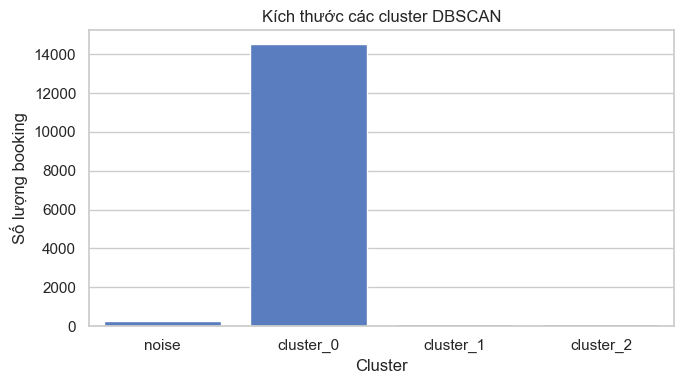

In [115]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=cluster_size,
    x="cluster_label",
    y="count"
)
plt.title("Kích thước các cluster DBSCAN")
plt.xlabel("Cluster")
plt.ylabel("Số lượng booking")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_cluster_size.png", dpi=300) 
plt.show()

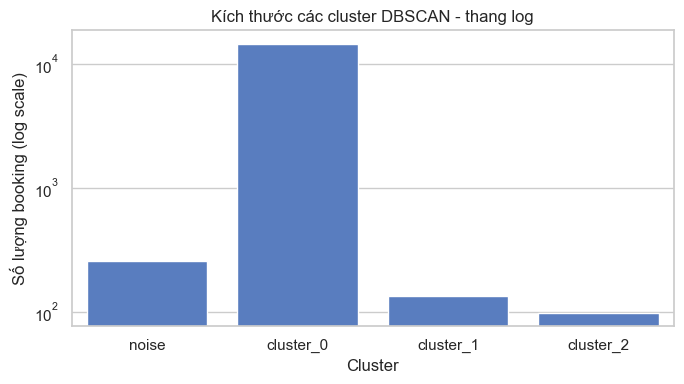

In [116]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=cluster_size,
    x="cluster_label",
    y="count"
)

plt.yscale("log")
plt.title("Kích thước các cluster DBSCAN - thang log")
plt.xlabel("Cluster")
plt.ylabel("Số lượng booking (log scale)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_cluster_size_thg_log.png", dpi=300) 
plt.show()

### 7. Tỷ lệ hủy phòng theo Cluster (Cancellation Rate by Cluster)


*Đoạn mã sau thực thi thuật toán DBSCAN để phân cụm.*


In [117]:
overall_cancel_rate = df_analysis["is_canceled"].mean()

cluster_cancel = (
    df_analysis
    .groupby("cluster")
    .agg(
        n=("is_canceled", "size"),
        cancellations=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

cluster_cancel["cluster_label"] = cluster_cancel["cluster"].map(
    lambda x: "noise" if x == -1 else f"cluster_{x}"
)
cluster_cancel["share_percent"] = (cluster_cancel["n"] / len(df_analysis) * 100).round(2)
cluster_cancel["cancellation_rate_percent"] = (cluster_cancel["cancellation_rate"] * 100).round(2)
cluster_cancel["lift_vs_sample"] = (cluster_cancel["cancellation_rate"] / overall_cancel_rate).round(2)

display(Markdown(f"**Cancellation rate trung bình của sample DBSCAN:** {overall_cancel_rate * 100:.2f}%"))

display(cluster_cancel[[
    "cluster", "cluster_label", "n", "share_percent",
    "cancellations", "cancellation_rate_percent", "lift_vs_sample"
]].sort_values("cancellation_rate_percent", ascending=False))


**Cancellation rate trung bình của sample DBSCAN:** 37.79%

,cluster,cluster_label,n,share_percent,cancellations,cancellation_rate_percent,lift_vs_sample
3,2,cluster_2,99,0.66,52,52.53,1.39
1,0,cluster_0,14509,96.73,5524,38.07,1.01
2,1,cluster_1,134,0.89,37,27.61,0.73
0,-1,noise,258,1.72,56,21.71,0.57


Biểu đồ cancellation rate


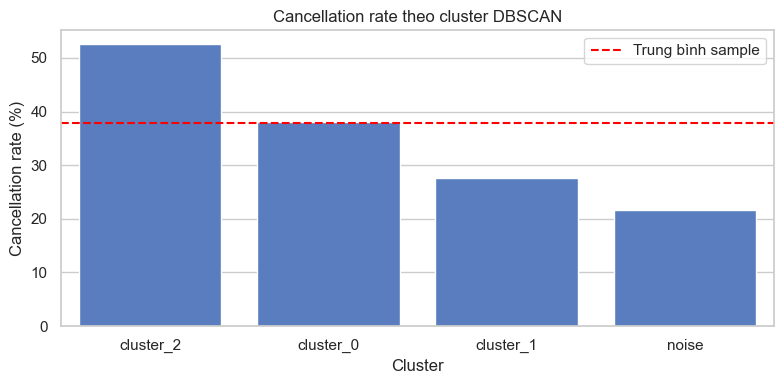

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = cluster_cancel.sort_values("cancellation_rate_percent", ascending=False).copy()

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="cluster_label", y="cancellation_rate_percent")
plt.axhline(overall_cancel_rate * 100, color="red", linestyle="--", label="Trung bình sample")
plt.title("Cancellation rate theo cluster DBSCAN")
plt.xlabel("Cluster")
plt.ylabel("Cancellation rate (%)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_Cancellation_rate.png", dpi=300) 
plt.show()


### 8. Chênh lệch so với trung bình sample


In [119]:
overall_profile = df_analysis[profile_cols].mean()

profile_diff = (
    df_analysis[df_analysis["cluster"] != -1]
    .groupby("cluster")[profile_cols]
    .mean()
    .subtract(overall_profile, axis=1)
    .round(3)
)

display(Markdown("**Chênh lệch trung bình của từng cluster so với toàn sample DBSCAN**"))
display(profile_diff)


**Chênh lệch trung bình của từng cluster so với toàn sample DBSCAN**

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,booking_changes,days_in_waiting_list,adr,total_stay,total_people,total_of_special_requests
cluster,,,,,,,,,,,,
0,0.001,-0.009,-0.019,-0.000,-0.001,-0.007,-0.010,-0.298,0.002,-0.011,-0.008,-0.000
1,0.001,0.205,0.645,0.049,-0.015,-0.007,0.074,6.352,-0.021,0.336,0.028,-0.365
2,0.074,0.379,0.453,0.028,-0.003,-0.007,0.056,-2.394,0.179,0.329,0.017,-0.294


### 9. Heatmap profiling


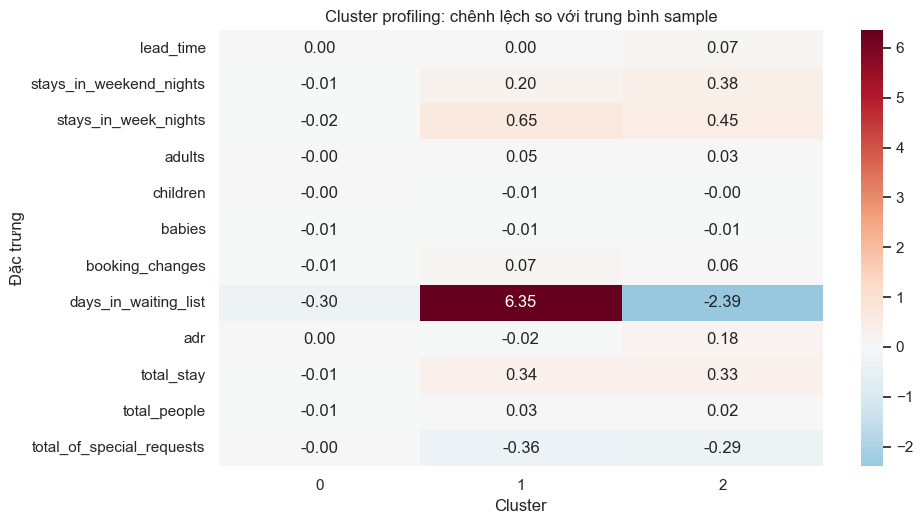

In [120]:
plt.figure(figsize=(10, max(3, 0.45 * len(profile_diff.columns))))
sns.heatmap(profile_diff.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Cluster profiling: chênh lệch so với trung bình sample")
plt.xlabel("Cluster")
plt.ylabel("Đặc trưng")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_cluster_profiling.png", dpi=300) 
plt.show()


## 10 Tổng hợp liên kỹ thuật

Classification cho biết dữ liệu có tín hiệu dự đoán `is_canceled`. Clustering cho biết các nhóm booking có đặc điểm hành vi khác nhau. Hai kỹ thuật được kết hợp bằng cách phân tích cancellation rate và profile của từng cluster.

Lưu ý: Classification dùng sample 40,000 dòng, DBSCAN dùng sample 15,000 dòng, nên notebook không so sánh trực tiếp từng dòng giữa hai kỹ thuật.

In [121]:
synthesis_rows = []

if not d1_metrics.empty:
    best_model = d1_metrics.sort_values("f1", ascending=False).iloc[0]["model"]
    synthesis_rows.append({
        "Nguồn": "Classification",
        "Kết quả dùng trong synthesis": f"Mô hình tốt nhất theo F1 trong D1_metrics.csv: {best_model}",
        "Giới hạn": "Sample 40,000 dòng; không dùng để so sánh row-level với DBSCAN sample"
    })
else:
    synthesis_rows.append({
        "Nguồn": "Classification",
        "Kết quả dùng trong synthesis": "Chưa có metric thật; cần chạy lại Bài 2 hoặc cung cấp D1_metrics.csv",
        "Giới hạn": "Không kết luận mô hình tốt hơn nếu thiếu metric"
    })

synthesis_rows.append({
    "Nguồn": "Clustering",
    "Kết quả dùng trong synthesis": (
        f"DBSCAN eps={DBSCAN_EPS}, min_samples={min_samples}, "
        f"sample {DBSCAN_SAMPLE_N:,}, tạo {n_clusters} cluster và {noise_rate:.2f}% noise"
    ),
    "Giới hạn": "Kết quả cluster chỉ dựa trên sample 15,000 dòng"
})

synthesis_rows.append({
    "Nguồn": "Cluster + is_canceled",
    "Kết quả dùng trong synthesis": "Tính cancellation rate, lift và profiling theo từng cluster",
    "Giới hạn": "is_canceled chỉ dùng sau clustering, không dùng làm input tạo cluster"
})

display(pd.DataFrame(synthesis_rows))

,Nguồn,Kết quả dùng trong synthesis,Giới hạn
0,Classification,Mô hình tốt nhất theo F1 trong D1_metrics.csv:...,"Sample 40,000 dòng; không dùng để so sánh row-..."
1,Clustering,"DBSCAN eps=9.0, min_samples=88, sample 15,000,...","Kết quả cluster chỉ dựa trên sample 15,000 dòng"
2,Cluster + is_canceled,"Tính cancellation rate, lift và profiling theo...","is_canceled chỉ dùng sau clustering, không dùn..."


## 11. Trả lời câu hỏi phân tích

**Guiding Question 1:** Những đặc điểm nào của booking có liên quan đến khả năng hủy, và có thể kết hợp Classification và Clustering để nhận diện sớm những booking có nguy cơ hủy cao hay không?

Classification từ Bài 2 cho biết dữ liệu có tín hiệu dự đoán `is_canceled`. Clustering cho biết các nhóm booking có tỷ lệ hủy khác nhau hay không.

In [122]:
best_cls_row = d1_metrics.sort_values("f1", ascending=False).iloc[0]

classification_summary = pd.DataFrame([{
    "best_model": best_cls_row["model"],
    "accuracy": round(best_cls_row["accuracy"], 4),
    "precision": round(best_cls_row["precision"], 4),
    "recall": round(best_cls_row["recall"], 4),
    "f1": round(best_cls_row["f1"], 4),
    "roc_auc": round(best_cls_row["roc_auc"], 4),
    "sample_note": "Classification Bài 2 dùng sample 40,000 dòng"
}])

display(classification_summary)

,best_model,accuracy,precision,recall,f1,roc_auc,sample_note
0,Decision Tree,0.7884,0.5788,0.8507,0.6888,0.8903,"Classification Bài 2 dùng sample 40,000 dòng"


*Tính toán tỷ lệ hủy phòng cho từng nhóm phân cụm.*

In [123]:
cluster_risk_summary = (
    cluster_cancel[cluster_cancel["cluster"] != -1]
    .sort_values("cancellation_rate", ascending=False)
    [[
        "cluster_label",
        "n",
        "share_percent",
        "cancellation_rate_percent",
        "lift_vs_sample"
    ]]
    .reset_index(drop=True)
)

display(cluster_risk_summary)

,cluster_label,n,share_percent,cancellation_rate_percent,lift_vs_sample
0,cluster_2,99,0.66,52.53,1.39
1,cluster_0,14509,96.73,38.07,1.01
2,cluster_1,134,0.89,27.61,0.73


### Trả lời Q1

Kết quả Classification cho thấy bài toán dự đoán hủy phòng có tín hiệu học được từ dữ liệu. Trong sample 40,000 dòng của Bài 2, Decision Tree là mô hình tốt nhất theo F1 và ROC-AUC.

Khi kết hợp với Clustering, DBSCAN cho thấy các nhóm booking có cancellation rate khác nhau. Vì `is_canceled` không được dùng để tạo cluster, sự khác biệt về tỷ lệ hủy giữa các cluster là bằng chứng bổ sung rằng các đặc điểm hành vi booking có liên quan đến rủi ro hủy.

Tuy nhiên, đây là quan hệ thống kê/tương quan, không phải quan hệ nhân quả. Ngoài ra, vì Classification và DBSCAN dùng hai sample khác nhau, notebook không kết luận row-level nếu chưa align dữ liệu.


### Tỷ lệ hủy phòng theo Cluster (Cancellation Rate by Cluster)


In [124]:
cluster_interpretation = []

for _, row in cluster_cancel[cluster_cancel["cluster"] != -1].sort_values("cluster").iterrows():
    cluster_id = int(row["cluster"])
    diff_row = profile_diff.loc[cluster_id]

    top_positive = diff_row.sort_values(ascending=False).head(3)
    top_negative = diff_row.sort_values(ascending=True).head(3)

    cluster_interpretation.append({
        "cluster": row["cluster_label"],
        "n": int(row["n"]),
        "share_percent": row["share_percent"],
        "cancellation_rate_percent": row["cancellation_rate_percent"],
        "lift_vs_sample": row["lift_vs_sample"],
        "risk_level": "Cao hơn trung bình" if row["cancellation_rate"] > overall_cancel_rate else "Thấp hơn hoặc bằng trung bình",
        "top_higher_than_sample": ", ".join([f"{idx} ({val:+.3f})" for idx, val in top_positive.items()]),
        "top_lower_than_sample": ", ".join([f"{idx} ({val:+.3f})" for idx, val in top_negative.items()])
    })

cluster_interpretation = pd.DataFrame(cluster_interpretation)
display(cluster_interpretation)

,cluster,n,share_percent,cancellation_rate_percent,lift_vs_sample,risk_level,top_higher_than_sample,top_lower_than_sample
0,cluster_0,14509,96.73,38.07,1.01,Cao hơn trung bình,"adr (+0.002), lead_time (+0.001), total_of_spe...","days_in_waiting_list (-0.298), stays_in_week_n..."
1,cluster_1,134,0.89,27.61,0.73,Thấp hơn hoặc bằng trung bình,"days_in_waiting_list (+6.352), stays_in_week_n...","total_of_special_requests (-0.365), adr (-0.02..."
2,cluster_2,99,0.66,52.53,1.39,Cao hơn trung bình,"stays_in_week_nights (+0.453), stays_in_weeken...","days_in_waiting_list (-2.394), total_of_specia..."


### Trả lời Q2

DBSCAN tạo ra 3 cluster chính và một nhóm noise. `cluster_0` chiếm phần lớn sample, trong khi `cluster_1` và `cluster_2` là các nhóm nhỏ hơn nhiều.

Các cluster có cancellation rate khác nhau. Trong kết quả hiện tại, `cluster_2` có cancellation rate cao nhất, `cluster_0` gần trung bình, còn `cluster_1` thấp hơn trung bình. Vì vậy, có thể kết luận rằng các nhóm booking được tạo bởi DBSCAN có khác biệt về tỷ lệ hủy.

Tuy nhiên, vì `cluster_1` và `cluster_2` có kích thước nhỏ, cần kiểm tra độ ổn định trước khi diễn giải quá mạnh.


## 12. Kết quả phát hiện chính


In [125]:
largest_cluster = cluster_cancel[cluster_cancel["cluster"] != -1].sort_values("n", ascending=False).iloc[0]
highest_risk_cluster = cluster_cancel[cluster_cancel["cluster"] != -1].sort_values("cancellation_rate", ascending=False).iloc[0]
lowest_risk_cluster = cluster_cancel[cluster_cancel["cluster"] != -1].sort_values("cancellation_rate", ascending=True).iloc[0]

findings = pd.DataFrame([
    {
        "Finding": "Dữ liệu có tín hiệu dự đoán hủy phòng",
        "Evidence": f"Decision Tree đạt F1={best_cls_row['f1']:.4f}, ROC-AUC={best_cls_row['roc_auc']:.4f}.",
        "Meaning": "Có thể dùng dữ liệu booking để hỗ trợ nhận diện sớm rủi ro hủy."
    },
    {
        "Finding": "Phần lớn booking thuộc một cluster hành vi chính",
        "Evidence": f"{largest_cluster['cluster_label']} chiếm {largest_cluster['share_percent']:.2f}% sample DBSCAN.",
        "Meaning": "Hành vi booking phổ biến chiếm tỷ trọng lớn; các nhóm nhỏ cần được xem như nhóm đặc biệt."
    },
    {
        "Finding": "Có cluster có tỷ lệ hủy cao hơn trung bình",
        "Evidence": f"{highest_risk_cluster['cluster_label']} có cancellation rate {highest_risk_cluster['cancellation_rate_percent']:.2f}%, lift={highest_risk_cluster['lift_vs_sample']:.2f}.",
        "Meaning": "Một số nhóm booking cần được theo dõi kỹ hơn về rủi ro hủy."
    },
    {
        "Finding": "Một số cluster có tỷ lệ hủy thấp hơn trung bình",
        "Evidence": f"{lowest_risk_cluster['cluster_label']} có cancellation rate {lowest_risk_cluster['cancellation_rate_percent']:.2f}%.",
        "Meaning": "Có thể ưu tiên nguồn lực theo nhóm thay vì áp dụng cùng một chính sách cho mọi booking."
    },
    {
        "Finding": "Cluster nhỏ cần diễn giải thận trọng",
        "Evidence": "cluster_1 và cluster_2 đều chiếm dưới 1% sample.",
        "Meaning": "Cần kiểm tra độ ổn định trước khi đưa ra khuyến nghị mạnh cho các nhóm nhỏ."
    },
])

display(findings)

,Finding,Evidence,Meaning
0,Dữ liệu có tín hiệu dự đoán hủy phòng,"Decision Tree đạt F1=0.6888, ROC-AUC=0.8903.",Có thể dùng dữ liệu booking để hỗ trợ nhận diệ...
1,Phần lớn booking thuộc một cluster hành vi chính,cluster_0 chiếm 96.73% sample DBSCAN.,Hành vi booking phổ biến chiếm tỷ trọng lớn; c...
2,Có cluster có tỷ lệ hủy cao hơn trung bình,"cluster_2 có cancellation rate 52.53%, lift=1.39.",Một số nhóm booking cần được theo dõi kỹ hơn v...
3,Một số cluster có tỷ lệ hủy thấp hơn trung bình,cluster_1 có cancellation rate 27.61%.,Có thể ưu tiên nguồn lực theo nhóm thay vì áp ...
4,Cluster nhỏ cần diễn giải thận trọng,cluster_1 và cluster_2 đều chiếm dưới 1% sample.,Cần kiểm tra độ ổn định trước khi đưa ra khuyế...


## 13. Kỹ thuật nâng cao tự tìm hiểu

`cluster_1` và `cluster_2` có kích thước nhỏ, nên cancellation rate của các cluster này có thể không ổn định. Vì vậy, dùng bootstrap confidence interval để kiểm tra độ ổn định của tỷ lệ hủy theo cluster.

Kỹ thuật này không cần thư viện mới ngoài `numpy` và `pandas`.


In [126]:
def bootstrap_cancel_rate(values, n_boot=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    values = np.asarray(values)
    boot_rates = []

    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_rates.append(sample.mean())

    boot_rates = np.asarray(boot_rates)
    return values.mean(), np.percentile(boot_rates, 2.5), np.percentile(boot_rates, 97.5)


bootstrap_rows = []

for cluster_id, group in df_analysis.groupby("cluster"):
    mean_rate, ci_low, ci_high = bootstrap_cancel_rate(
        group["is_canceled"].values,
        n_boot=2000,
        random_state=RANDOM_STATE + int(cluster_id) + 10
    )

    bootstrap_rows.append({
        "cluster": cluster_id,
        "cluster_label": "noise" if cluster_id == -1 else f"cluster_{cluster_id}",
        "n": len(group),
        "cancel_rate_percent": round(mean_rate * 100, 2),
        "ci_95_low_percent": round(ci_low * 100, 2),
        "ci_95_high_percent": round(ci_high * 100, 2),
        "ci_width_percent": round((ci_high - ci_low) * 100, 2),
    })

bootstrap_ci = pd.DataFrame(bootstrap_rows).sort_values("cancel_rate_percent", ascending=False)
display(bootstrap_ci)

,cluster,cluster_label,n,cancel_rate_percent,ci_95_low_percent,ci_95_high_percent,ci_width_percent
3,2,cluster_2,99,52.53,42.42,62.63,20.20
1,0,cluster_0,14509,38.07,37.28,38.83,1.55
2,1,cluster_1,134,27.61,20.15,35.82,15.67
0,-1,noise,258,21.71,16.67,26.74,10.08


## 14. Thảo luận và hạn chế

Các kết quả trong notebook chỉ cho thấy mối liên hệ thống kê giữa đặc điểm booking, cluster và khả năng hủy, không chứng minh quan hệ nhân quả.

Classification được chạy trên sample 40,000 dòng, còn DBSCAN được chạy trên sample 15,000 dòng. Vì vậy, notebook chỉ tổng hợp ở mức xu hướng, không so sánh từng dòng.

DBSCAN nhạy với `eps`, `min_samples` và cách chuẩn hóa dữ liệu. Ngoài ra, một cluster chiếm phần lớn sample, còn các cluster khác rất nhỏ, nên cần thận trọng khi diễn giải nhóm nhỏ.


*Đoạn mã sau thực thi trực quan hóa bằng biểu đồ.*


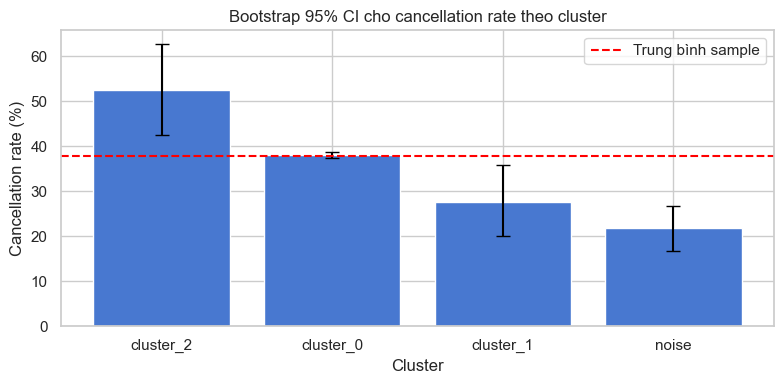

In [127]:
plt.figure(figsize=(8, 4))

plot_ci = bootstrap_ci.sort_values("cancel_rate_percent", ascending=False).copy()
yerr = [
    plot_ci["cancel_rate_percent"] - plot_ci["ci_95_low_percent"],
    plot_ci["ci_95_high_percent"] - plot_ci["cancel_rate_percent"]
]

plt.bar(plot_ci["cluster_label"], plot_ci["cancel_rate_percent"])
plt.errorbar(
    plot_ci["cluster_label"],
    plot_ci["cancel_rate_percent"],
    yerr=yerr,
    fmt="none",
    color="black",
    capsize=5
)
plt.axhline(overall_cancel_rate * 100, color="red", linestyle="--", label="Trung bình sample")
plt.title("Bootstrap 95% CI cho cancellation rate theo cluster")
plt.xlabel("Cluster")
plt.ylabel("Cancellation rate (%)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bieu_do_bootstrap_ci.png", dpi=300) 
plt.show()

Kết quả Bootstrap CI cho thấy các cluster nhỏ có khoảng tin cậy rộng hơn so với cluster lớn. Điều này củng cố nhận xét rằng cancellation rate của `cluster_1` và `cluster_2` cần được diễn giải thận trọng. Vì vậy, các cluster nhỏ có thể được xem là tín hiệu rủi ro đáng chú ý, nhưng chưa nên dùng như kết luận tuyệt đối nếu chưa kiểm tra thêm trên sample khác.


## 15. Khuyến nghị ứng dụng

1. Ưu tiên theo dõi nhóm booking có cancellation rate cao hơn trung bình.
2. Không áp dụng cùng một chính sách cho mọi booking; nên phân tầng booking theo mức rủi ro.
3. Dùng Classification như công cụ cảnh báo sớm, dùng Clustering để giải thích nhóm hành vi.
4. Thận trọng với cluster nhỏ; cần kiểm tra thêm bằng bootstrap hoặc chạy lại trên sample khác.
5. Tiếp tục lưu metric và kết quả trung gian như `D1_metrics.csv` để báo cáo dễ kiểm chứng.


## 16. Kết luận

Notebook đã xây dựng một phân tích tổng hợp cho bộ dữ liệu Hotel Booking Demand dựa trên hai kỹ thuật chính: Classification và Clustering.

Classification cho thấy dữ liệu booking có tín hiệu để dự đoán khả năng hủy. Trong kết quả Bài 2, Decision Tree cho kết quả tốt hơn Logistic Regression theo F1 và ROC-AUC trên sample 40,000 dòng.

Clustering bằng DBSCAN cho thấy booking có thể được chia thành các nhóm hành vi khác nhau. Khi ghép `is_canceled` sau bước clustering, các cluster có cancellation rate khác nhau, cho thấy việc phân nhóm có thể hỗ trợ phân tích rủi ro hủy.

Hai kỹ thuật bổ sung cho nhau: Classification hỗ trợ nhận diện nguy cơ hủy, còn Clustering giúp diễn giải các nhóm booking và so sánh mức độ rủi ro giữa các nhóm. Do sample khác nhau và một số cluster nhỏ, kết luận cần được diễn giải thận trọng.
